## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb
from tigramite.independence_tests.gpdc_torch import GPDCtorch
from tigramite.independence_tests.gsquared import Gsquared
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.lpcmci import LPCMCI

from csi_vae_gumbel.settings import Settings

settings = Settings()

IND_TEST = "cmisymb"
DEBUG = False
SAVE_FIGS = True
FILTER_THRESHOLD = 0.2
TAU_MIN = 1
TAU_MAX = settings.test_window_size // settings.train_window_size - 1

In [2]:
is_ind_test_categorical = IND_TEST in ["cmiknn", "gsquared", "cmisymb"]

match IND_TEST:
    case "parcorr":
        ind_test = ParCorr(significance="analytic")
    case "robustparcorr":
        ind_test = RobustParCorr(significance="analytic")
    case "gpdc":
        ind_test = GPDCtorch()
    case "gsquared":
        ind_test = Gsquared()
    case "cmisymb":
        ind_test = CMIsymb()
    case "cmiknn":
        ind_test = CMIknn()
    case _:
        msg = f"Unknown independence test: {IND_TEST}"
        raise ValueError(msg)

## Dataset

We use the complete dataset for causal inference, withouy any train/test split.

In [3]:
# Shape will be (T, latent_dim, n_categories)
latents_raw = np.load(f"../{settings.study_path}/latents/latents_{'hard' if is_ind_test_categorical else 'soft'}.npy")

# Shape will be (T,)
labels = np.load(f"../{settings.study_path}/latents/labels.npy")

if is_ind_test_categorical:
    # Get the argmax indices (the most likely category) for each latent dimension
    latents = np.argmax(latents_raw, axis=2)
else:
    # Get the probability of the most likely category for each latent dimension
    latents = torch.softmax(torch.from_numpy(latents_raw), dim=2).numpy()
    latents = np.max(latents, axis=2)

labelled_causal_data = {}

# 2. Split and THEN shift per activity
for label in np.unique(labels):
    # Extract latents for this specific movement sequence
    activity_latents = latents[labels == label]
    activity_latents = activity_latents[::settings.train_window_size]
    labelled_causal_data[int(label)] = activity_latents

## Causal Analysis

In [4]:
def compute_gsquared_signs(data: np.ndarray, val_matrix: np.ndarray) -> None:
    """For each link found by Tigramite (nonzero in val_matrix), compute the Spearman correlation."""
    n_vars = val_matrix.shape[0]

    for i in range(n_vars):
        for j in range(n_vars):
            for tau in range(TAU_MIN, TAU_MAX + 1):
                # If Tigramite found a link (nonzero value in val_matrix)
                strength = val_matrix[i, j, tau]

                if strength > 0:  # G2 values are always positive
                    # Get the two time-series aligned by the lag (tau)
                    # X is the cause (at t - tau), Y is the effect (at t)
                    y_series = data[tau:, j]
                    x_series = data[:-tau, i]

                    # Calculate Spearman correlation to find the sign
                    res = stats.spearmanr(x_series, y_series)
                    rho = res.statistic  # pyright: ignore[reportAttributeAccessIssue]

                    # OPTIONAL: Manually update val_matrix with the sign for plotting
                    # This makes the red/blue plot work correctly
                    val_matrix[i, j, tau] *= np.sign(rho)

Walk


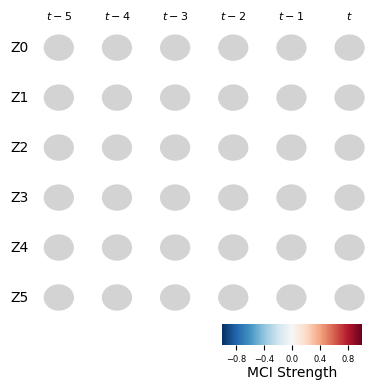

Run


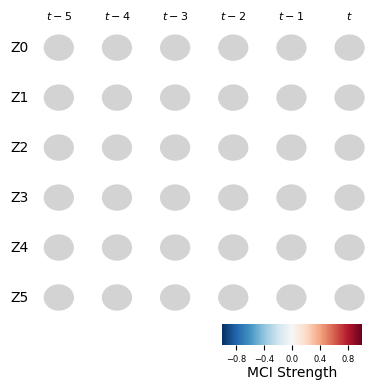

In [ ]:
var_names = [f"Z{i}" for i in range(latents.shape[1])]

# 2. Iterate through each activity
for label_id, data in labelled_causal_data.items():
    activity_name = settings.activities[label_id]

    # Initialize Tigramite DataFrame
    # Note: 'datatypes' should be 'discrete' for Gsquared
    data_type = np.ones_like(data) if is_ind_test_categorical else np.zeros_like(data)
    dataframe = pp.DataFrame(data, var_names=var_names, data_type=data_type)

    # 3. Run LPCMCI
    # LPCMCI is robust to latent common causes (unobserved drivers in CSI)
    lpcmci = LPCMCI(dataframe=dataframe, cond_ind_test=ind_test, verbosity=DEBUG)

    # pc_alpha is the significance level for the conditional independence tests
    results = lpcmci.run_lpcmci(
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        pc_alpha=1e-3,
    )

    # Create copies so you don't mutate the original results
    filtered_val_matrix = results["val_matrix"].copy()
    filtered_graph = results["graph"].copy()

    if IND_TEST == "gsquared":
        compute_gsquared_signs(data, filtered_val_matrix)

    # Find indices where the absolute strength is below the threshold and zero them
    weak_links = np.abs(filtered_val_matrix) < FILTER_THRESHOLD
    filtered_val_matrix[weak_links] = 0
    filtered_graph[weak_links] = ""

    for i in range(filtered_graph.shape[0]):
        for j in range(filtered_graph.shape[1]):
            for tau in range(filtered_graph.shape[2]):
                # Remove bidirected (confounded) links
                if filtered_graph[i, j, tau] == "<->" or "o" in filtered_graph[i, j, tau]:
                    filtered_graph[i, j, tau] = ""
                    filtered_val_matrix[i, j, tau] = 0

    print(activity_name)

    # 4. Plotting
    # Time series graph is best for t, t-1, t-2 visualization
    fig, ax = tp.plot_time_series_graph(
        figsize=(4, 4),
        val_matrix=filtered_val_matrix,
        graph=filtered_graph,
        var_names=var_names,
        link_colorbar_label="MCI Strength",
    )

    plt.tight_layout()

    if SAVE_FIGS:
        out_dir = Path(f"../{settings.study_path}/causal_analysis/{IND_TEST}")
        out_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_dir / f"{activity_name}.pdf")

    plt.show()